# CARGA DE DATOS Y LIBRERIAS

In [115]:
# INSTALACIÓN DE PAQUETES NECESARIOS (ejecutar solo una vez)
! pip install gdown kmodes scikit-learn pandas numpy matplotlib seaborn joblib -q

In [116]:
# IMPORTACIÓN DE LIBRERÍAS
import pandas as pd
import numpy as np
import gdown
import os
import warnings
from datetime import datetime
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest, RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from kmodes.kprototypes import KPrototypes

# Configuración
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
plt.style.use('seaborn-v0_8-darkgrid')

In [117]:
# FUNCIONES DE UTILIDAD PARA OPTIMIZAR MEMORIA Y VISUALIZACIÓN

def optimizar_memoria(df):
    """Reduce el uso de memoria optimizando tipos de datos."""
    memoria_inicial = df.memory_usage().sum() / 1024**2
    
    for columna in df.columns:
        tipo = str(df[columna].dtype)
        
        # Optimizar números enteros
        if tipo.startswith('int'):
            c_min = df[columna].min()
            c_max = df[columna].max()
            
            if c_min > np.iinfo(np.int8).min and c_max < np.iinfo(np.int8).max:
                df[columna] = df[columna].astype(np.int8)
            elif c_min > np.iinfo(np.int16).min and c_max < np.iinfo(np.int16).max:
                df[columna] = df[columna].astype(np.int16)
            elif c_min > np.iinfo(np.int32).min and c_max < np.iinfo(np.int32).max:
                df[columna] = df[columna].astype(np.int32)
            else:
                df[columna] = df[columna].astype(np.int64)
                
        # Optimizar números decimales
        elif tipo.startswith('float'):
            df[columna] = df[columna].astype(np.float32)
            
        # Optimizar texto
        elif tipo == 'object':
            if df[columna].nunique() / len(df) < 0.5:
                df[columna] = df[columna].astype('category')
    
    memoria_final = df.memory_usage().sum() / 1024**2
    reduccion = 100 * (memoria_inicial - memoria_final) / memoria_inicial
    
    print(f"Memoria: {memoria_inicial:.1f}MB → {memoria_final:.1f}MB ({reduccion:.1f}% reducción)")
    return df

def mostrar_info_dataset(df, nombre="Dataset"):
    return df.head(5)

def descargar_dataset(file_id, nombre_archivo):
    """Descarga el dataset desde Google Drive si no existe."""
    if not os.path.exists(nombre_archivo):
        url = f'https://drive.google.com/uc?id={file_id}'
        gdown.download(url, nombre_archivo, quiet=False)
        print(f"Dataset descargado: {nombre_archivo}")
    else:
        print(f"Dataset ya existe: {nombre_archivo}")

In [118]:
# CONFIGURACIÓN PRINCIPAL
CONFIG = {
    'FILE_ID': '1VNArYveijKBtBKdIo7YCbVQITWxuyTQc',
    'FILE_NAME': 'DataCoSupplyChainDataset.csv',
    'COLUMNAS_NECESARIAS': [
        'Customer Id', 'Customer Lname', 'Customer Zipcode',
        'Benefit per order', 'Sales per customer', 'Order Item Discount Rate',
        'Order Item Quantity', 'Order Id', 'Customer Segment', 'Order Region',
        'Order City', 'Order Country', 'Customer City', 'Customer State',
        'Customer Country', 'Latitude', 'Longitude', 'Sales', 'Category Name',
        'Product Name', 'Order Item Discount', 'Type', 'Delivery Status',
        'Late_delivery_risk', 'Category Id', 'Department Id', 'Market',
        'Order Customer Id', 'order date (DateOrders)', 'Order Item Product Price',
        'Order Item Profit Ratio', 'Order Item Total', 'Order Profit Per Order',
        'Order Status', 'Product Card Id', 'Product Category Id', 'Product Price',
        'shipping date (DateOrders)', 'Shipping Mode'
    ]
}

In [119]:
#CARGA Y LIMPIEZA DE DATOS

# Cargar solo las columnas necesarias
df = pd.read_csv(CONFIG['FILE_NAME'], encoding='latin-1', usecols=CONFIG['COLUMNAS_NECESARIAS'])

# Eliminar filas con datos críticos faltantes
filas_iniciales = len(df)
df.dropna(subset=['Customer Lname', 'Customer Zipcode'], inplace=True)
filas_finales = len(df)

# Eliminar columnas innecesarias
columnas_a_eliminar = ['Customer Email', 'Customer Password', 'Product Image', 'Product Description', 'Order Zipcode']
columnas_eliminadas = [c for c in columnas_a_eliminar if c in df.columns]
df.drop(columns=columnas_eliminadas, inplace=True, errors='ignore')

# Optimizar memoria
df = optimizar_memoria(df)

# Mostrar información
mostrar_info_dataset(df, "Dataset Original")

Memoria: 55.1MB → 22.8MB (58.6% reducción)


,Type,Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,Customer Country,Customer Id,Customer Lname,Customer Segment,Customer State,Customer Zipcode,Department Id,Latitude,Longitude,Market,Order City,Order Country,Order Customer Id,order date (DateOrders),Order Id,Order Item Discount,Order Item Discount Rate,Order Item Product Price,Order Item Profit Ratio,Order Item Quantity,Sales,Order Item Total,Order Profit Per Order,Order Region,Order Status,Product Card Id,Product Category Id,Product Name,Product Price,shipping date (DateOrders),Shipping Mode
0,DEBIT,91.250000,314.640015,Advance shipping,0,73,Sporting Goods,Caguas,Puerto Rico,20755,Holloway,Consumer,PR,725.0,2,18.251453,-66.037056,Pacific Asia,Bekasi,Indonesia,20755,1/31/2018 22:56,77202,13.110000,0.04,327.75,0.29,1,327.75,314.640015,91.250000,Southeast Asia,COMPLETE,1360,73,Smart watch,327.75,2/3/2018 22:56,Standard Class
1,TRANSFER,-249.089996,311.359985,Late delivery,1,73,Sporting Goods,Caguas,Puerto Rico,19492,Luna,Consumer,PR,725.0,2,18.279451,-66.037064,Pacific Asia,Bikaner,India,19492,1/13/2018 12:27,75939,16.389999,0.05,327.75,-0.80,1,327.75,311.359985,-249.089996,South Asia,PENDING,1360,73,Smart watch,327.75,1/18/2018 12:27,Standard Class
2,CASH,-247.779999,309.720001,Shipping on time,0,73,Sporting Goods,San Jose,EE. UU.,19491,Maldonado,Consumer,CA,95125.0,2,37.292233,-121.881279,Pacific Asia,Bikaner,India,19491,1/13/2018 12:06,75938,18.030001,0.06,327.75,-0.80,1,327.75,309.720001,-247.779999,South Asia,CLOSED,1360,73,Smart watch,327.75,1/17/2018 12:06,Standard Class
3,DEBIT,22.860001,304.809998,Advance shipping,0,73,Sporting Goods,Los Angeles,EE. UU.,19490,Tate,Home Office,CA,90027.0,2,34.125946,-118.291016,Pacific Asia,Townsville,Australia,19490,1/13/2018 11:45,75937,22.940001,0.07,327.75,0.08,1,327.75,304.809998,22.860001,Oceania,COMPLETE,1360,73,Smart watch,327.75,1/16/2018 11:45,Standard Class
4,PAYMENT,134.210007,298.250000,Advance shipping,0,73,Sporting Goods,Caguas,Puerto Rico,19489,Hendricks,Corporate,PR,725.0,2,18.253769,-66.037048,Pacific Asia,Townsville,Australia,19489,1/13/2018 11:24,75936,29.500000,0.09,327.75,0.45,1,327.75,298.250000,134.210007,Oceania,PENDING_PAYMENT,1360,73,Smart watch,327.75,1/15/2018 11:24,Standard Class


# AGRUPACION DE CLIENTES

In [120]:
# Agrupar datos por cliente

print("Agrupacion datos por cliente")
df_clientes = df.groupby("Customer Id").agg({
    'Benefit per order': 'sum',
    'Sales per customer': 'sum',
    'Order Item Discount Rate': 'mean',
    'Order Item Quantity': 'mean',
    'Order Id': 'nunique'
}).reset_index()

print(f"{len(df_clientes):,} clientes únicos identificados")
variables_modelo = ["Benefit per order", "Sales per customer", "Order Item Discount Rate", "Order Item Quantity", "Order Id"]

modelo_anomalias = IsolationForest(contamination=0.07, random_state=13)
df_clientes["es_anomalia"] = modelo_anomalias.fit_predict(df_clientes[variables_modelo])

# Mostrar resultados
conteo_anomalias = df_clientes["es_anomalia"].value_counts()
print(f"\nRESULTADOS DETECCIÓN ANOMALÍAS:")
print(f"   • Clientes normales (1): {conteo_anomalias.get(1, 0):,}")
print(f"   • Clientes anómalos (-1): {conteo_anomalias.get(-1, 0):,}")
print(f"   • Porcentaje de anomalías: {100*conteo_anomalias.get(-1, 0)/len(df_clientes):.1f}%")

# Separar clientes regulares y anómalos
clientes_regulares = df_clientes[(df_clientes["es_anomalia"] == 1) | (df_clientes["Benefit per order"] >= 1000)]
clientes_anomalos = df_clientes[(df_clientes["es_anomalia"] == -1) & (df_clientes["Benefit per order"] < 1000)]

print(f"\nCLIENTES PARA ANÁLISIS:")
print(f"   • Clientes regulares (incluye VIP): {len(clientes_regulares):,}")
print(f"   • Clientes anómalos (excluidos): {len(clientes_anomalos):,}")

Agrupacion datos por cliente
20,641 clientes únicos identificados

RESULTADOS DETECCIÓN ANOMALÍAS:
   • Clientes normales (1): 19,196
   • Clientes anómalos (-1): 1,445
   • Porcentaje de anomalías: 7.0%

CLIENTES PARA ANÁLISIS:
   • Clientes regulares (incluye VIP): 19,532
   • Clientes anómalos (excluidos): 1,109


In [121]:
# Preparar DataFrame final con información demográfica
df_modelo = clientes_regulares.copy()

# Agregar información demográfica
columnas_demograficas = ['Customer Segment', 'Order Region', 'Order City', 'Order Country']
info_demografica = df.groupby('Customer Id')[columnas_demograficas].first().reset_index()

# Fusionar datos
df_final = pd.merge(
    df_modelo, 
    info_demografica, 
    left_on='Customer Id', 
    right_on='Customer Id', 
    how='left'
)

# Eliminar columna temporal
if 'es_anomalia' in df_final.columns:
    df_final = df_final.drop(columns=['es_anomalia'])

print(f"DataFrame:")
print(f"   • Total clientes: {len(df_final):,}")
print(f"   • Total columnas: {len(df_final.columns)}")

# Mostrar información
mostrar_info_dataset(df_final, "DataFrame Final")

DataFrame:
   • Total clientes: 19,532
   • Total columnas: 10


,Customer Id,Benefit per order,Sales per customer,Order Item Discount Rate,Order Item Quantity,Order Id,Customer Segment,Order Region,Order City,Order Country
0,2,208.739990,1618.660034,0.126000,1.900000,4,Consumer,Central America,San Pedro Sula,Honduras
1,3,334.489990,3189.199951,0.105000,1.833333,5,Consumer,Oceania,Mount Gambier,Australia
2,4,-439.979980,1480.709961,0.135000,2.428571,4,Consumer,West Asia,Mersin,Turquía
3,5,309.850006,1101.920044,0.140000,2.571429,3,Home Office,West Africa,Lagos,Nigeria
4,6,893.650024,2954.320068,0.106667,3.133333,4,Consumer,Central America,Cancún,México


## SEGMENTACION

In [122]:
#SEGMENTACIÓN DE CLIENTES (K-Prototypes)

# Separar variables numéricas y categóricas
variables_numericas = ['Benefit per order', 'Sales per customer', 'Order Item Discount Rate', 'Order Item Quantity', 'Order Id']
variables_categoricas = ['Customer Segment', 'Order Region', 'Order City', 'Order Country']

# Escalar variables numéricas
scaler = StandardScaler()
matriz_numerica = scaler.fit_transform(df_final[variables_numericas])

# Preparar matriz categórica
matriz_categorica = df_final[variables_categoricas].values

# Combinar matrices
matriz_total = np.hstack((matriz_numerica, matriz_categorica))

# Calcular índices de columnas categóricas
indice_inicio_categorico = len(variables_numericas)
indices_categoricos = list(range(indice_inicio_categorico, indice_inicio_categorico + len(variables_categoricas)))

print(f"  Matriz total: {matriz_total.shape[0]:,} clientes x {matriz_total.shape[1]} características")
print(f"  Variables categóricas en índices: {indices_categoricos}")
modelo_kproto = KPrototypes(n_clusters=3, init="Cao", verbose=1, random_state=10)

# Entrenar modelo y asignar segmentos
segmentos = modelo_kproto.fit_predict(matriz_total, categorical=indices_categoricos)

# Agregar segmentos al DataFrame
df_final['segmento'] = segmentos

  Matriz total: 19,532 clientes x 9 características
  Variables categóricas en índices: [5, 6, 7, 8]
Initialization method and algorithm are deterministic. Setting n_init to 1.
Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run: 1, iteration: 1/100, moves: 3645, ncost: 72462.45087771595
Run: 1, iteration: 2/100, moves: 706, ncost: 72297.24076168425
Run: 1, iteration: 3/100, moves: 226, ncost: 72272.64025882892
Run: 1, iteration: 4/100, moves: 86, ncost: 72269.4997053382
Run: 1, iteration: 5/100, moves: 46, ncost: 72268.657308591
Run: 1, iteration: 6/100, moves: 28, ncost: 72268.32699059616
Run: 1, iteration: 7/100, moves: 15, ncost: 72268.24739427447
Run: 1, iteration: 8/100, moves: 4, ncost: 72268.2363919939
Run: 1, iteration: 9/100, moves: 1, ncost: 72268.23547545169
Run: 1, iteration: 10/100, moves: 0, ncost: 72268.23547545169
Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run: 2, iteration: 1/100, moves: 7260, ncost:

In [123]:
#ANÁLISIS DE SEGMENTOS DE CLIENTES

# Clientes por segmento
conteo_segmentos = df_final['segmento'].value_counts().sort_index()

print("DISTRIBUCIÓN DE CLIENTES POR SEGMENTO:")
for segmento, conteo in conteo_segmentos.items():
    porcentaje = 100 * conteo / len(df_final)
    print(f"   Segmento {segmento}: {conteo:,} clientes ({porcentaje:.1f}%)")

# Calcular estadísticas por segmento
print("\nESTADÍSTICAS POR SEGMENTO:")
estadisticas = df_final.groupby('segmento').agg({
    'Benefit per order': ['mean', 'std', 'min', 'max'],
    'Sales per customer': ['mean', 'std'],
    'Order Item Discount Rate': 'mean',
    'Order Item Quantity': 'mean',
    'Order Id': 'mean'
}).round(2)

print(estadisticas)
beneficios_medios = df_final.groupby('segmento')['Benefit per order'].mean()
segmentos_ordenados = beneficios_medios.sort_values(ascending=False).index.tolist()

nombres_segmentos = {}
for i, segmento in enumerate(segmentos_ordenados):
    if i == 0:
        nombres_segmentos[segmento] = "VIP (Alto Valor)"
    elif i == 1:
        nombres_segmentos[segmento] = "Regular (Valor Medio)"
    else:
        nombres_segmentos[segmento] = "Ocasional (Bajo Valor)"

# Agregar nombres al DataFrame
df_final['nombre_segmento'] = df_final['segmento'].map(nombres_segmentos)

# Distribución final
print("\nDISTRIBUCIÓN FINAL:")
for nombre in df_final['nombre_segmento'].unique():
    conteo = (df_final['nombre_segmento'] == nombre).sum()
    porcentaje = 100 * conteo / len(df_final)
    print(f"{nombre}: {conteo:,} clientes ({porcentaje:.1f}%)")

# Guardar DataFrame segmentado
df_segmentado = df_final.copy()
print(f"\nDataFrame segmentado como 'df_segmentado' ({len(df_segmentado):,} filas)")

DISTRIBUCIÓN DE CLIENTES POR SEGMENTO:
   Segmento 0: 5,367 clientes (27.5%)
   Segmento 1: 9,951 clientes (50.9%)
   Segmento 2: 4,214 clientes (21.6%)

ESTADÍSTICAS POR SEGMENTO:
         Benefit per order                                        \
                      mean         std          min          max   
segmento                                                           
0                36.970001  164.460007 -1149.619995   708.750000   
1               373.230011  409.519989 -1281.000000  2441.969971   
2                34.360001  140.789993  -993.260010   646.799988   

         Sales per customer              Order Item Discount Rate  \
                       mean          std                     mean   
segmento                                                            
0                371.779999   408.809998                     0.05   
1               2661.189941  1122.689941                     0.10   
2                317.390015   364.250000                     0.16

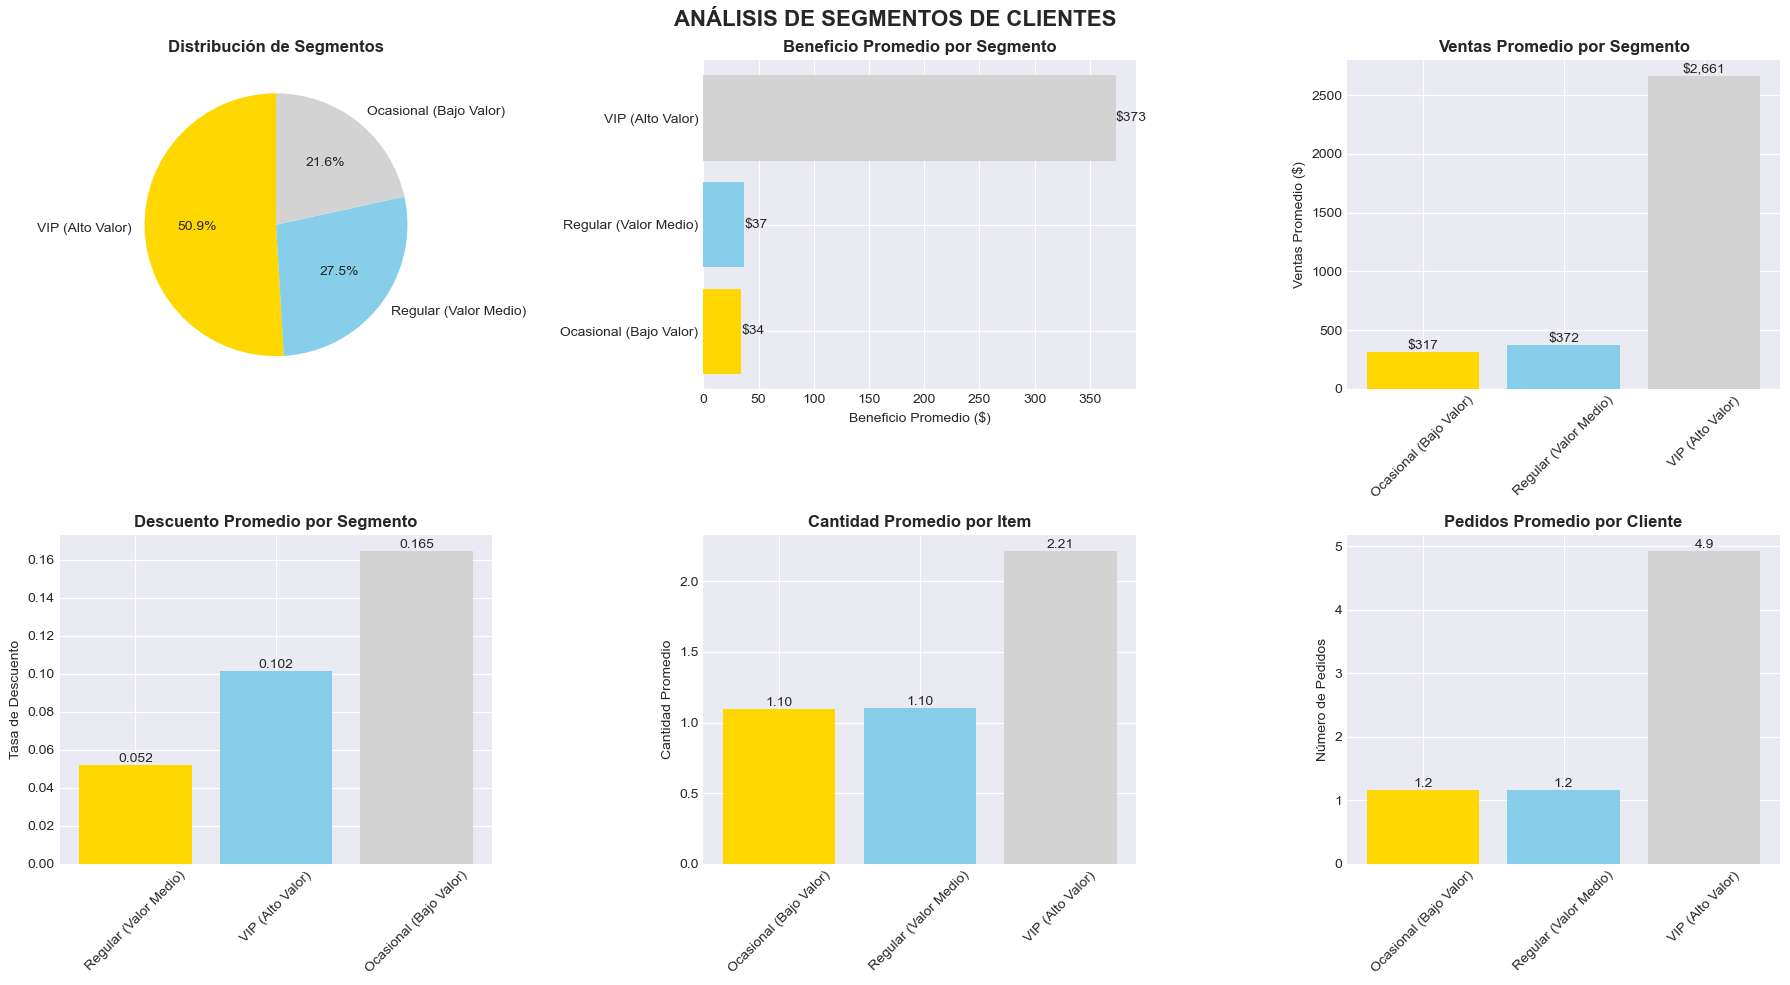

In [124]:
#VISUALIZACIÓN DE SEGMENTOS

# Crear figura con múltiples gráficos
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('ANÁLISIS DE SEGMENTOS DE CLIENTES', fontsize=16, fontweight='bold')

# 1. Distribución de segmentos
ax1 = axes[0, 0]
distribucion = df_segmentado['nombre_segmento'].value_counts()
colors = ['gold', 'skyblue', 'lightgray']
ax1.pie(distribucion.values, labels=distribucion.index, autopct='%1.1f%%', 
        colors=colors, startangle=90)
ax1.set_title('Distribución de Segmentos', fontweight='bold')

# 2. Beneficio promedio por segmento
ax2 = axes[0, 1]
beneficio_promedio = df_segmentado.groupby('nombre_segmento')['Benefit per order'].mean().sort_values()
ax2.barh(beneficio_promedio.index, beneficio_promedio.values, color=colors)
ax2.set_xlabel('Beneficio Promedio ($)')
ax2.set_title('Beneficio Promedio por Segmento', fontweight='bold')
for i, v in enumerate(beneficio_promedio.values):
    ax2.text(v, i, f'${v:,.0f}', va='center')

# 3. Ventas promedio por segmento
ax3 = axes[0, 2]
ventas_promedio = df_segmentado.groupby('nombre_segmento')['Sales per customer'].mean().sort_values()
ax3.bar(ventas_promedio.index, ventas_promedio.values, color=colors)
ax3.set_ylabel('Ventas Promedio ($)')
ax3.set_title('Ventas Promedio por Segmento', fontweight='bold')
ax3.tick_params(axis='x', rotation=45)
for i, v in enumerate(ventas_promedio.values):
    ax3.text(i, v, f'${v:,.0f}', ha='center', va='bottom')

# 4. Descuento promedio por segmento
ax4 = axes[1, 0]
descuento_promedio = df_segmentado.groupby('nombre_segmento')['Order Item Discount Rate'].mean().sort_values()
ax4.bar(descuento_promedio.index, descuento_promedio.values, color=colors)
ax4.set_ylabel('Tasa de Descuento')
ax4.set_title('Descuento Promedio por Segmento', fontweight='bold')
ax4.tick_params(axis='x', rotation=45)
for i, v in enumerate(descuento_promedio.values):
    ax4.text(i, v, f'{v:.3f}', ha='center', va='bottom')

# 5. Cantidad promedio por segmento
ax5 = axes[1, 1]
cantidad_promedio = df_segmentado.groupby('nombre_segmento')['Order Item Quantity'].mean().sort_values()
ax5.bar(cantidad_promedio.index, cantidad_promedio.values, color=colors)
ax5.set_ylabel('Cantidad Promedio')
ax5.set_title('Cantidad Promedio por Item', fontweight='bold')
ax5.tick_params(axis='x', rotation=45)
for i, v in enumerate(cantidad_promedio.values):
    ax5.text(i, v, f'{v:.2f}', ha='center', va='bottom')

# 6. Pedidos promedio por segmento
ax6 = axes[1, 2]
pedidos_promedio = df_segmentado.groupby('nombre_segmento')['Order Id'].mean().sort_values()
ax6.bar(pedidos_promedio.index, pedidos_promedio.values, color=colors)
ax6.set_ylabel('Número de Pedidos')
ax6.set_title('Pedidos Promedio por Cliente', fontweight='bold')
ax6.tick_params(axis='x', rotation=45)
for i, v in enumerate(pedidos_promedio.values):
    ax6.text(i, v, f'{v:.1f}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

In [125]:
#MODELO DE CLASIFICACIÓN (Random Forest)

# Definir variables predictoras y objetivo
variables_modelo = [
    'Benefit per order', 
    'Sales per customer',
    'Order Item Discount Rate', 
    'Order Item Quantity', 
    'Order Id'
]

# Verificar que todas las variables existan
variables_faltantes = [v for v in variables_modelo if v not in df_segmentado.columns]
if variables_faltantes:
    print(f"Variables faltantes: {variables_faltantes}")

# Preparar X (características) e y (etiquetas)
X = df_segmentado[variables_modelo]
y = df_segmentado['segmento']

print("\n DATOS PARA ENTRENAMIENTO:")
print(f"Total de clientes: {len(X):,}")
print(f"Variables predictoras: {len(variables_modelo)}")
print(f"Clases únicas: {sorted(y.unique())}")

print("\nDISTRIBUCIÓN DE CLASES:")
for clase in sorted(y.unique()):
    conteo = (y == clase).sum()
    porcentaje = 100 * conteo / len(y)
    nombre = nombres_segmentos.get(clase, f"Clase {clase}")
    print(f"Clase {clase} ({nombre}): {conteo:,} ({porcentaje:.1f}%)")


 DATOS PARA ENTRENAMIENTO:
Total de clientes: 19,532
Variables predictoras: 5
Clases únicas: [0, 1, 2]

DISTRIBUCIÓN DE CLASES:
Clase 0 (Regular (Valor Medio)): 5,367 (27.5%)
Clase 1 (VIP (Alto Valor)): 9,951 (50.9%)
Clase 2 (Ocasional (Bajo Valor)): 4,214 (21.6%)


## ENTRENAMIENTO

In [126]:
#ENTRENANDO MODELO RANDOM FOREST
# Dividir datos en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42,
    stratify=y
)

print(f"Conjunto de entrenamiento: {len(X_train):,} muestras")
print(f"Conjunto de prueba: {len(X_test):,} muestras")

# Crear y entrenar modelo
modelo_clasificacion = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

scores_cv = cross_val_score(modelo_clasificacion, X_train, y_train, cv=5)
print(f"Precisión CV (5 folds): {scores_cv.mean()*100:.1f}% (±{scores_cv.std()*100:.1f}%)")
modelo_clasificacion.fit(X_train, y_train)

# Evaluar en conjunto de prueba
y_pred = modelo_clasificacion.predict(X_test)
precision = accuracy_score(y_test, y_pred)
print(f"Precisión en prueba: {precision*100:.1f}%")

# Importancia de variables
importancia = dict(zip(variables_modelo, modelo_clasificacion.feature_importances_))
print("\nIMPORTANCIA DE VARIABLES:")
for variable, importancia_valor in sorted(importancia.items(), key=lambda x: x[1], reverse=True):
    print(f"   • {variable}: {importancia_valor*100:.1f}%")

# Mostrar matriz de confusión
print("\nMATRIZ DE CONFUSIÓN:")
cm = confusion_matrix(y_test, y_pred)
cm_df = pd.DataFrame(cm, 
                     index=[f'Real {i}' for i in sorted(y.unique())], 
                     columns=[f'Pred {i}' for i in sorted(y.unique())])
print(cm_df)

Conjunto de entrenamiento: 15,625 muestras
Conjunto de prueba: 3,907 muestras
Precisión CV (5 folds): 98.8% (±0.1%)
Precisión en prueba: 98.5%

IMPORTANCIA DE VARIABLES:
   • Order Item Discount Rate: 37.9%
   • Order Id: 24.7%
   • Order Item Quantity: 22.4%
   • Sales per customer: 12.9%
   • Benefit per order: 2.1%

MATRIZ DE CONFUSIÓN:
        Pred 0  Pred 1  Pred 2
Real 0    1046      28       0
Real 1       7    1979       4
Real 2       0      20     823


## PREDICCION

In [127]:
#PREDICCIÓN DE CLIENTES

# Definir función para clasificar cliente
def clasificar_cliente(beneficio, ventas, descuento, cantidad, pedidos):
    # Crear array con los datos del cliente
    datos_cliente = np.array([[beneficio, ventas, descuento, cantidad, pedidos]])
    
    # Predecir categoría
    categoria_num = modelo_clasificacion.predict(datos_cliente)[0]
    probabilidades = modelo_clasificacion.predict_proba(datos_cliente)[0]
    
    # Definir nombres de categorías
    nombres_categorias = {
        0: {"nombre": "CLIENTE VIP", "color": "dorado"},
        1: {"nombre": "CLIENTE OCASIONAL", "color": "gris"},
        2: {"nombre": "CLIENTE REGULAR", "color": "azul"}
    }
    
    # Obtener información de la categoría predicha
    if categoria_num in nombres_categorias:
        info = nombres_categorias[categoria_num]
    else:
        info = {"nombre": f"CLASE {categoria_num}", "color": "negro"}
    
    # Crear respuesta estructurada
    resultado = {
        "categoria_numero": int(categoria_num),
        "categoria_nombre": info["nombre"],
        "color": info["color"],
        "probabilidades": {
            "VIP": f"{probabilidades[0]*100:.1f}%",
            "Ocasional": f"{probabilidades[1]*100:.1f}%",
            "Regular": f"{probabilidades[2]*100:.1f}%"
        },
        "confianza": f"{max(probabilidades)*100:.1f}%",
        "caracteristicas": {
            "beneficio": beneficio,
            "ventas": ventas,
            "descuento": f"{descuento*100:.1f}%",
            "cantidad_promedio": cantidad,
            "numero_pedidos": pedidos
        }
    }
    
    return resultado

# Función para mostrar resultados
def mostrar_prediccion(resultado):
    print(f"{resultado['categoria_nombre']}")

    print(f"Categoría: {resultado['categoria_nombre']}")
    print(f"Confianza: {resultado['confianza']}")
    print(f"Probabilidades:")
    print(f" • VIP: {resultado['probabilidades']['VIP']}")
    print(f" • Ocasional: {resultado['probabilidades']['Ocasional']}")
    print(f" • Regular: {resultado['probabilidades']['Regular']}")
    print("\nCaracterísticas del cliente:")
    print(f"  Beneficio por orden: ${resultado['caracteristicas']['beneficio']:,.2f}")
    print(f"  Ventas por cliente: ${resultado['caracteristicas']['ventas']:,.2f}")
    print(f"  Descuento promedio: {resultado['caracteristicas']['descuento']}")
    print(f"  Cantidad promedio: {resultado['caracteristicas']['cantidad_promedio']:.2f}")
    print(f"  Número de pedidos: {resultado['caracteristicas']['numero_pedidos']}")
print("\nUSO: clasificar_cliente(beneficio, ventas, descuento, cantidad, pedidos)")
print("USO: mostrar_prediccion(resultado)")


USO: clasificar_cliente(beneficio, ventas, descuento, cantidad, pedidos)
USO: mostrar_prediccion(resultado)


In [128]:
#PRUEBAS CLIENTES

resultado1 = clasificar_cliente(
    beneficio=1800.0,
    ventas=5500.0,
    descuento=0.07,
    cantidad=3.2,
    pedidos=12
)
mostrar_prediccion(resultado1)

resultado2 = clasificar_cliente(
    beneficio=320.0,
    ventas=1800.0,
    descuento=0.12,
    cantidad=1.8,
    pedidos=6
)
mostrar_prediccion(resultado2)

resultado3 = clasificar_cliente(
    beneficio=45.0,
    ventas=280.0,
    descuento=0.18,
    cantidad=1.1,
    pedidos=2
)
mostrar_prediccion(resultado3)

CLIENTE OCASIONAL
Categoría: CLIENTE OCASIONAL
Confianza: 100.0%
Probabilidades:
 • VIP: 0.0%
 • Ocasional: 100.0%
 • Regular: 0.0%

Características del cliente:
  Beneficio por orden: $1,800.00
  Ventas por cliente: $5,500.00
  Descuento promedio: 7.0%
  Cantidad promedio: 3.20
  Número de pedidos: 12
CLIENTE OCASIONAL
Categoría: CLIENTE OCASIONAL
Confianza: 99.8%
Probabilidades:
 • VIP: 0.1%
 • Ocasional: 99.8%
 • Regular: 0.1%

Características del cliente:
  Beneficio por orden: $320.00
  Ventas por cliente: $1,800.00
  Descuento promedio: 12.0%
  Cantidad promedio: 1.80
  Número de pedidos: 6
CLIENTE REGULAR
Categoría: CLIENTE REGULAR
Confianza: 99.4%
Probabilidades:
 • VIP: 0.6%
 • Ocasional: 0.0%
 • Regular: 99.4%

Características del cliente:
  Beneficio por orden: $45.00
  Ventas por cliente: $280.00
  Descuento promedio: 18.0%
  Cantidad promedio: 1.10
  Número de pedidos: 2


In [129]:
#CLIENTES REALES DEL DATASET"

def analizar_cliente_real(id_cliente):
    print(f"\nCLIENTE ID: {id_cliente}")
    
    # Buscar cliente
    cliente = df_segmentado[df_segmentado['Customer Id'] == id_cliente]
    
    if cliente.empty:
        print(f"Cliente no encontrado")
        return None
    
    datos = cliente.iloc[0]
    
    # Información del cliente
    info = {
        'segmento_real': datos['segmento'],
        'nombre_segmento_real': datos['nombre_segmento'],
        'beneficio': datos['Benefit per order'],
        'ventas': datos['Sales per customer'],
        'descuento': datos['Order Item Discount Rate'],
        'cantidad': datos['Order Item Quantity'],
        'pedidos': datos['Order Id'],
        'region': datos.get('Order Region', 'N/A'),
        'ciudad': datos.get('Order City', 'N/A'),
        'pais': datos.get('Order Country', 'N/A')
    }
    
    # Predecir con el modelo
    prediccion = clasificar_cliente(
        info['beneficio'],
        info['ventas'],
        info['descuento'],
        info['cantidad'],
        info['pedidos']
    )
    
    # Comparar resultados
    coincide = prediccion['categoria_numero'] == info['segmento_real']
    
    # Mostrar resultados
    print(f"SEGMENTO REAL: {info['nombre_segmento_real']} (Clase {info['segmento_real']})")
    print(f"PREDICCIÓN MODELO: {prediccion['categoria_nombre']}")
    
    if coincide:
        print(f"¡COINCIDE!")
    else:
        print(f"NO COINCIDE - Diferencia: {abs(prediccion['categoria_numero'] - info['segmento_real'])}")
    
    print(f"\nUBICACIÓN: {info['ciudad']}, {info['region']}, {info['pais']}")
    print(f"BENEFICIO: ${info['beneficio']:,.2f}")
    print(f"VENTAS: ${info['ventas']:,.2f}")
    print(f"DESCUENTO: {info['descuento']*100:.1f}%")
    
    print(f"\nPROBABILIDADES:")
    for cat, prob in prediccion['probabilidades'].items():
        print(f"   • {cat}: {prob}")
    
    return {
        'info': info,
        'prediccion': prediccion,
        'coincide': coincide
    }

# Analizar algunos clientes aleatorios
print("\nANALIZANDO 3 CLIENTES ALEATORIOS:")
ids_aleatorios = df_segmentado['Customer Id'].sample(3, random_state=42).tolist()
for id_cliente in ids_aleatorios:
    analizar_cliente_real(id_cliente)


ANALIZANDO 3 CLIENTES ALEATORIOS:

CLIENTE ID: 6596


SEGMENTO REAL: Regular (Valor Medio) (Clase 0)
PREDICCIÓN MODELO: CLIENTE VIP
¡COINCIDE!

UBICACIÓN: Petapa, Central America, Guatemala
BENEFICIO: $-152.15
VENTAS: $611.20
DESCUENTO: 9.3%

PROBABILIDADES:
   • VIP: 94.3%
   • Ocasional: 3.6%
   • Regular: 2.1%

CLIENTE ID: 9146
SEGMENTO REAL: VIP (Alto Valor) (Clase 1)
PREDICCIÓN MODELO: CLIENTE OCASIONAL
¡COINCIDE!

UBICACIÓN: London, Northern Europe, Reino Unido
BENEFICIO: $334.80
VENTAS: $2,075.94
DESCUENTO: 11.6%

PROBABILIDADES:
   • VIP: 0.0%
   • Ocasional: 100.0%
   • Regular: 0.0%

CLIENTE ID: 6648
SEGMENTO REAL: VIP (Alto Valor) (Clase 1)
PREDICCIÓN MODELO: CLIENTE OCASIONAL
¡COINCIDE!

UBICACIÓN: Nagpur, South Asia, India
BENEFICIO: $392.91
VENTAS: $1,378.59
DESCUENTO: 10.9%

PROBABILIDADES:
   • VIP: 0.1%
   • Ocasional: 99.4%
   • Regular: 0.6%


## RESULTADOS

In [130]:
#MODELO Y RESULTADOS"

# Guardar el modelo entrenado
try:
    # Guardar modelo de clasificación
    joblib.dump(modelo_clasificacion, 'modelo_clasificador_clientes.pkl')
    
    # Guardar scaler
    joblib.dump(scaler, 'scaler_clientes.pkl')
    
    # Guardar DataFrame segmentado
    df_segmentado.to_csv('clientes_segmentados.csv', index=False)
    
    # Guardar información del modelo
    info_modelo = {
        'fecha_entrenamiento': datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
        'precision': precision,
        'variables': variables_modelo,
        'nombres_segmentos': nombres_segmentos,
        'tamano_entrenamiento': len(X_train),
        'tamano_prueba': len(X_test)
    }
    
    joblib.dump(info_modelo, 'info_modelo.pkl')
    
    print(f"\nARCHIVOS GUARDADOS:")
    print(f"   1. modelo_clasificador_clientes.pkl - Modelo Random Forest")
    print(f"   2. scaler_clientes.pkl - Escalador de características")
    print(f"   3. clientes_segmentados.csv - Dataset con segmentación")
    print(f"   4. info_modelo.pkl - Metadatos del modelo")
    
except Exception as e:
    print(f"Error al guardar archivos: {e}")
    print("Los modelos y datos permanecen en memoria")

print("\nRESUMEN FINAL:")
print(f"   • Clientes analizados: {len(df):,}")
print(f"   • Clientes segmentados: {len(df_segmentado):,}")
print(f"   • Segmentos identificados: {len(nombres_segmentos)}")
print(f"   • Precisión del modelo: {precision*100:.1f}%")
print(f"   • Clientes VIP identificados: {(df_segmentado['nombre_segmento'] == 'VIP (Alto Valor)').sum():,}")
print(f"   • Archivos guardados: 4")

print("\nSISTEMA LISTO PARA USAR:")
print("   • clasificar_cliente() - Predecir categoría de nuevo cliente")
print("   • mostrar_prediccion() - Mostrar resultados formateados")
print("   • analizar_cliente_real() - Analizar cliente existente")


ARCHIVOS GUARDADOS:
   1. modelo_clasificador_clientes.pkl - Modelo Random Forest
   2. scaler_clientes.pkl - Escalador de características
   3. clientes_segmentados.csv - Dataset con segmentación
   4. info_modelo.pkl - Metadatos del modelo

RESUMEN FINAL:
   • Clientes analizados: 180,508
   • Clientes segmentados: 19,532
   • Segmentos identificados: 3
   • Precisión del modelo: 98.5%
   • Clientes VIP identificados: 9,951
   • Archivos guardados: 4

SISTEMA LISTO PARA USAR:
   • clasificar_cliente() - Predecir categoría de nuevo cliente
   • mostrar_prediccion() - Mostrar resultados formateados
   • analizar_cliente_real() - Analizar cliente existente


In [131]:
#LIMPIEZA

# Liberar memoria de objetos grandes que ya no se necesitan
objetos_a_eliminar = ['df', 'df_clientes', 'clientes_regulares', 'clientes_anomalos', 
                      'matriz_total', 'X_train', 'X_test', 'y_train', 'y_test']

for obj in objetos_a_eliminar:
    if obj in globals():
        del globals()[obj]
        print(f"   • {obj} eliminado")

# Recolectar basura
import gc
gc.collect()

print("\nDATOS DISPONIBLES EN MEMORIA:")
print("   1. df_segmentado - DataFrame con clientes segmentados")
print("   2. modelo_clasificacion - Modelo Random Forest entrenado")
print("   3. clasificar_cliente() - Función para predecir clientes")
print("   4. mostrar_prediccion() - Función para mostrar resultados")
print("   5. analizar_cliente_real() - Función para analizar clientes existentes")


   • df eliminado
   • df_clientes eliminado
   • clientes_regulares eliminado
   • clientes_anomalos eliminado
   • matriz_total eliminado
   • X_train eliminado
   • X_test eliminado
   • y_train eliminado
   • y_test eliminado

DATOS DISPONIBLES EN MEMORIA:
   1. df_segmentado - DataFrame con clientes segmentados
   2. modelo_clasificacion - Modelo Random Forest entrenado
   3. clasificar_cliente() - Función para predecir clientes
   4. mostrar_prediccion() - Función para mostrar resultados
   5. analizar_cliente_real() - Función para analizar clientes existentes


# GEOGRAFICA

In [132]:
"""
ANÁLISIS GEOGRÁFICO - SISTEMA COMPLETO
Clasificación por Región, País, Estado y Ciudad usando Random Forest
"""

# Importar librerías necesarias
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import warnings
warnings.filterwarnings('ignore')


In [133]:
# RECUPERAR DATOS GEOGRÁFICOS PARA CLASIFICACIÓN
print("RECUPERANDO DATOS GEOGRÁFICOS...")

# Cargar columnas geográficas necesarias desde el dataset original
columnas_geograficas = [
    'Customer Id', 
    'Customer City', 
    'Customer State', 
    'Customer Country',
    'Customer Zipcode',
    'Order City', 
    'Order Region', 
    'Order Country',
    'Order State',
    'Latitude', 
    'Longitude',
    'Market'
]

# Cargar solo las columnas geográficas (no repitas la carga si ya tienes df)
df_geo = pd.read_csv(
    CONFIG['FILE_NAME'], 
    encoding='latin-1', 
    usecols=columnas_geograficas
)

# Limpiar duplicados: mantener solo un registro por Customer Id
df_geo_clean = df_geo.drop_duplicates(subset=['Customer Id']).reset_index(drop=True)

print(f"✓ Datos geográficos cargados: {len(df_geo_clean):,} clientes únicos")
print(f"✓ Columnas disponibles: {list(df_geo_clean.columns)}")

RECUPERANDO DATOS GEOGRÁFICOS...
✓ Datos geográficos cargados: 20,652 clientes únicos
✓ Columnas disponibles: ['Customer City', 'Customer Country', 'Customer Id', 'Customer State', 'Customer Zipcode', 'Latitude', 'Longitude', 'Market', 'Order City', 'Order Country', 'Order Region', 'Order State']


In [134]:
# UNIR DATOS GEOGRÁFICOS CON SEGMENTOS
print("\nUNIENDO DATOS GEOGRÁFICOS CON SEGMENTACIÓN...")

# Verificar que tenemos los mismos clientes
clientes_en_segmentacion = set(df_segmentado['Customer Id'])
clientes_en_geograficos = set(df_geo_clean['Customer Id'])
clientes_comunes = clientes_en_segmentacion.intersection(clientes_en_geograficos)

print(f"• Clientes en segmentación: {len(clientes_en_segmentacion):,}")
print(f"• Clientes con datos geográficos: {len(clientes_en_geograficos):,}")
print(f"• Clientes comunes: {len(clientes_comunes):,}")

# Unir los datos
df_segmentado_completo = df_segmentado.merge(
    df_geo_clean,
    on='Customer Id',
    how='left',
    suffixes=('', '_geo')
)

print(f"\n✓ Datos unidos correctamente")
print(f"✓ Nuevo tamaño del DataFrame: {len(df_segmentado_completo):,} filas")
print(f"✓ Nuevas columnas añadidas: {list(set(df_segmentado_completo.columns) - set(df_segmentado.columns))}")

# Actualizar df_segmentado
df_segmentado = df_segmentado_completo.copy()


UNIENDO DATOS GEOGRÁFICOS CON SEGMENTACIÓN...
• Clientes en segmentación: 19,532
• Clientes con datos geográficos: 20,652
• Clientes comunes: 19,532

✓ Datos unidos correctamente
✓ Nuevo tamaño del DataFrame: 19,532 filas
✓ Nuevas columnas añadidas: ['Longitude', 'Customer State', 'Latitude', 'Order Country_geo', 'Order State', 'Market', 'Order Region_geo', 'Customer Country', 'Order City_geo', 'Customer City', 'Customer Zipcode']


In [135]:
# CLASIFICACIÓN POR REGIÓN (si está disponible)
region_disponible = False
columna_region = None

if 'Order Region' in df_segmentado.columns:
    columna_region = 'Order Region'
    region_disponible = True
elif 'Customer Region' in df_segmentado.columns:
    columna_region = 'Customer Region'
    region_disponible = True

if region_disponible:
    # Primero, verificar qué datos tenemos
    print(f"\nVERIFICANDO DATOS PARA REGIÓN '{columna_region}':")
    print(f"• Total filas: {len(df_segmentado):,}")
    print(f"• Filas con región no nula: {df_segmentado[columna_region].notna().sum():,}")
    print(f"• Filas con latitud no nula: {df_segmentado['Latitude'].notna().sum():,}")
    print(f"• Filas con longitud no nula: {df_segmentado['Longitude'].notna().sum():,}")
    
    # Filtrar solo filas con todos los datos necesarios
    mascara_completos = (
        df_segmentado[columna_region].notna() & 
        df_segmentado['Latitude'].notna() & 
        df_segmentado['Longitude'].notna()
    )
    
    df_region = df_segmentado[mascara_completos].copy()
    
    print(f"\nDATOS PARA CLASIFICACIÓN POR REGIÓN:")
    print(f"• Filas con datos completos: {len(df_region):,} ({len(df_region)/len(df_segmentado)*100:.1f}%)")
    
    if len(df_region) > 0:
        # Agrupar por región y obtener coordenadas promedio
        region_coords = df_region.groupby(columna_region).agg({
            'Latitude': 'mean',
            'Longitude': 'mean'
        }).reset_index()
        
        print(f"• Regiones únicas: {len(region_coords)}")
        print(f"\nMuestra de regiones encontradas:")
        print(region_coords.head())
        
        # Crear clasificación simple: Norte, Sur, Este, Oeste basado en hemisferios
        def clasificar_region(lat, lon):
            if pd.isna(lat) or pd.isna(lon):
                return "Desconocido"
            
            if lat >= 0:
                hemisferio_lat = "Norte"
            else:
                hemisferio_lat = "Sur"
            
            if lon >= 0:
                hemisferio_lon = "Este"
            else:
                hemisferio_lon = "Oeste"
            
            return f"{hemisferio_lat}_{hemisferio_lon}"
        
        region_coords['Clasificacion_Region'] = region_coords.apply(
            lambda row: clasificar_region(row['Latitude'], row['Longitude']), axis=1
        )
        
        print("\nCLASIFICACIÓN POR REGIÓN:")
        print(region_coords[['Order Region', 'Clasificacion_Region', 'Latitude', 'Longitude']].head())
        
        # Unir clasificación al DataFrame original
        df_segmentado = df_segmentado.merge(
            region_coords[[columna_region, 'Clasificacion_Region']], 
            on=columna_region, 
            how='left'
        )
        
        print("\n✓ Clasificación por región añadida al DataFrame")
        print(f"• Clasificación aplicada a: {df_segmentado['Clasificacion_Region'].notna().sum():,} clientes")
    else:
        print("⚠️ No hay datos suficientes para clasificar por región")
else:
    print("❌ No se encuentran columnas de región")


VERIFICANDO DATOS PARA REGIÓN 'Order Region':
• Total filas: 19,532
• Filas con región no nula: 19,532
• Filas con latitud no nula: 19,532
• Filas con longitud no nula: 19,532

DATOS PARA CLASIFICACIÓN POR REGIÓN:
• Filas con datos completos: 19,532 (100.0%)
• Regiones únicas: 23

Muestra de regiones encontradas:
      Order Region   Latitude  Longitude
0           Canada  28.125631 -80.089146
1        Caribbean  29.407599 -83.657914
2   Central Africa  28.624660 -81.795427
3  Central America  29.578658 -84.535229
4     Central Asia  29.202976 -86.260004

CLASIFICACIÓN POR REGIÓN:
      Order Region Clasificacion_Region   Latitude  Longitude
0           Canada          Norte_Oeste  28.125631 -80.089146
1        Caribbean          Norte_Oeste  29.407599 -83.657914
2   Central Africa          Norte_Oeste  28.624660 -81.795427
3  Central America          Norte_Oeste  29.578658 -84.535229
4     Central Asia          Norte_Oeste  29.202976 -86.260004

✓ Clasificación por región añadida al 

In [136]:
# Verificar qué DataFrames tenemos disponibles
dataframes_disponibles = [name for name in globals() if isinstance(globals()[name], pd.DataFrame)]
print(f"DataFrames disponibles: {dataframes_disponibles}")

# Determinar qué DataFrame usar
if 'df_segmentado' in globals():
    df_geo_base = df_segmentado.copy()
    print("Usando: df_segmentado")
elif 'df_final' in globals():
    df_geo_base = df_final.copy()
    print("Usando: df_final")
elif 'df' in globals():
    df_geo_base = df.copy()
    print("Usando: df (dataset original)")
else:
    raise ValueError("No se encontró ningún DataFrame con datos")

# Verificar columnas geográficas disponibles
print("\nCOLUMNAS GEOGRÁFICAS DISPONIBLES:")
columnas_geo = ['Customer City', 'Customer State', 'Customer Country', 
                'Order City', 'Order State', 'Order Region', 
                'Order Country', 'Latitude', 'Longitude']

columnas_disponibles = [col for col in columnas_geo if col in df_geo_base.columns]
print(f"Encontradas: {len(columnas_disponibles)}/{len(columnas_geo)}")
for col in columnas_disponibles:
    print(f"     - {col}")

if len(columnas_disponibles) < 3:
    print("Pocas columnas geográficas disponibles")

DataFrames disponibles: ['_', '__', '___', '_8', '_9', '_11', '_13', '_16', 'df_modelo', 'info_demografica', 'df_final', '_19', '_20', '_21', 'estadisticas', 'df_segmentado', 'X', 'cm_df', '_49', '_51', 'df_geo_base', '_79', '_85', 'df_geo', 'df_geo_clean', 'df_segmentado_completo', 'df_region', 'region_coords', 'X_region', 'X_train_r', 'X_test_r', 'df_pais', 'X_pais', 'X_train_p', 'X_test_p', 'df_estado', 'X_estado', 'X_train_e', 'X_test_e', 'df_ciudad', 'X_ciudad', 'X_train_c', 'X_test_c', 'pais_coords', 'estado_coords', '_119', '_121']
Usando: df_segmentado

COLUMNAS GEOGRÁFICAS DISPONIBLES:
Encontradas: 9/9
     - Customer City
     - Customer State
     - Customer Country
     - Order City
     - Order State
     - Order Region
     - Order Country
     - Latitude
     - Longitude


In [137]:
#CLASIFICACIÓN POR REGIONES
# Verificar que tenemos la columna de región
if 'Order Region' not in df_geo_base.columns:
    print("No se encuentra la columna 'Order Region'")
    
    # Buscar columnas alternativas que puedan contener información de región
    columnas_alternativas = [col for col in df_geo_base.columns if 'region' in col.lower()]
    if columnas_alternativas:
        print(f"   Columnas alternativas encontradas: {columnas_alternativas}")
        # Usar la primera alternativa
        columna_region = columnas_alternativas[0]
        df_geo_base['Order Region'] = df_geo_base[columna_region]
        print(f"   Usando columna: {columna_region}")
    else:
        print("No se encontraron columnas de región, saltando análisis por región")
        region_disponible = False
else:
    columna_region = 'Order Region'
    region_disponible = True

if region_disponible:
    # Filtrar datos con región disponible
    df_region = df_geo_base.dropna(subset=[columna_region, 'Latitude', 'Longitude']).copy()
    
    print(f"\nDATOS PARA CLASIFICACIÓN POR REGIÓN:")
    print(f"• Filas con datos completos: {len(df_region):,}")
    print(f"• Regiones únicas: {df_region[columna_region].nunique()}")
    print(f"• Regiones más comunes:")
    
    top_regiones = df_region[columna_region].value_counts().head(10)
    for i, (region, count) in enumerate(top_regiones.items(), 1):
        porcentaje = 100 * count / len(df_region)
        print(f"{i}. {region}: {count:,} ({porcentaje:.1f}%)")
    
    # Preparar variables
    X_region = df_region[['Latitude', 'Longitude']]
    y_region = df_region[columna_region]
    
    # Dividir datos
    X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
        X_region, y_region, test_size=0.25, random_state=42, stratify=y_region
    )
    
    # Entrenar modelo
    print("\nEntrenando modelo Random Forest para regiones...")
    modelo_region = RandomForestClassifier(
        n_estimators=150,
        max_depth=15,
        min_samples_split=5,
        random_state=42,
        n_jobs=-1
    )
    
    modelo_region.fit(X_train_r, y_train_r)
    
    # Evaluar
    y_pred_r = modelo_region.predict(X_test_r)
    precision_region = accuracy_score(y_test_r, y_pred_r)
    
    print(f"\nMODELO DE REGIONES ENTRENADO")
    print(f"• Precisión: {precision_region*100:.2f}%")
    print(f"• Regiones clasificables: {len(y_region.unique())}")
    
    # Función para predecir región
    def predecir_region(latitud, longitud):
        datos = np.array([[latitud, longitud]])
        region_predicha = modelo_region.predict(datos)[0]
        
        # Obtener probabilidades
        if hasattr(modelo_region, 'predict_proba'):
            probabilidades = modelo_region.predict_proba(datos)[0]
            clases = modelo_region.classes_
            prob_dict = {clases[i]: f"{prob*100:.1f}%" for i, prob in enumerate(probabilidades)}
            prob_top = sorted(zip(clases, probabilidades), key=lambda x: x[1], reverse=True)[:3]
        else:
            prob_dict = {}
            prob_top = []
        
        return {
            'region': region_predicha,
            'probabilidades': prob_dict,
            'top_3': prob_top,
            'coordenadas': {'latitud': latitud, 'longitud': longitud}
        }
    
    # Ejemplo de predicción
    print("\nEJEMPLO DE PREDICCIÓN POR REGIÓN:")
    ejemplo_lat = df_region['Latitude'].mean()
    ejemplo_lon = df_region['Longitude'].mean()
    
    resultado_ejemplo = predecir_region(ejemplo_lat, ejemplo_lon)
    print(f"Coordenadas: {ejemplo_lat:.4f}, {ejemplo_lon:.4f}")
    print(f"Región predicha: {resultado_ejemplo['region']}")
    
    if resultado_ejemplo['top_3']:
        print(f"   🎯 Top 3 regiones más probables:")
        for region, prob in resultado_ejemplo['top_3']:
            print(f"      • {region}: {prob*100:.1f}%")
    
    print("\nSistema de clasificación por regiones listo")
    print("Usa: predecir_region(latitud, longitud)")


DATOS PARA CLASIFICACIÓN POR REGIÓN:
• Filas con datos completos: 19,532
• Regiones únicas: 23
• Regiones más comunes:
1. Western Europe: 3,221 (16.5%)
2. Southeast Asia: 2,256 (11.6%)
3. Oceania: 1,951 (10.0%)
4. Central America: 1,901 (9.7%)
5. Eastern Asia: 1,687 (8.6%)
6. South Asia: 1,526 (7.8%)
7. Northern Europe: 1,182 (6.1%)
8. Southern Europe: 1,152 (5.9%)
9. South America: 1,012 (5.2%)
10. Caribbean: 542 (2.8%)

Entrenando modelo Random Forest para regiones...

MODELO DE REGIONES ENTRENADO
• Precisión: 13.68%
• Regiones clasificables: 23

EJEMPLO DE PREDICCIÓN POR REGIÓN:
Coordenadas: 29.7651, -85.0148
Región predicha: Western Europe
   🎯 Top 3 regiones más probables:
      • Western Europe: 13.0%
      • Central America: 12.0%
      • Oceania: 11.8%

Sistema de clasificación por regiones listo
Usa: predecir_region(latitud, longitud)


In [138]:
# CLASIFICACIÓN POR PAÍS (si está disponible)
pais_disponible = False
columna_pais = None

if 'Order Country' in df_segmentado.columns:
    columna_pais = 'Order Country'
    pais_disponible = True
elif 'Customer Country' in df_segmentado.columns:
    columna_pais = 'Customer Country'
    pais_disponible = True

if pais_disponible:
    # Verificar qué datos tenemos
    print(f"\nVERIFICANDO DATOS PARA PAÍS '{columna_pais}':")
    print(f"• Total filas: {len(df_segmentado):,}")
    print(f"• Filas con país no nulo: {df_segmentado[columna_pais].notna().sum():,}")
    
    # Filtrar solo filas con todos los datos necesarios
    mascara_completos = (
        df_segmentado[columna_pais].notna() & 
        df_segmentado['Latitude'].notna() & 
        df_segmentado['Longitude'].notna()
    )
    
    df_pais = df_segmentado[mascara_completos].copy()

    # Limpiar nombres de países
    df_pais[columna_pais] = df_pais[columna_pais].astype(str).str.strip()
    
    print(f"\nDATOS PARA CLASIFICACIÓN POR PAÍS:")
    print(f"• Filas con datos completos: {len(df_pais):,} ({len(df_pais)/len(df_segmentado)*100:.1f}%)")
    
    if len(df_pais) > 0:
        # Agrupar por país y obtener coordenadas promedio
        pais_coords = df_pais.groupby(columna_pais).agg({
            'Latitude': 'mean',
            'Longitude': 'mean'
        }).reset_index()
        
        print(f"• Países únicos: {len(pais_coords)}")
        print(f"\nMuestra de países encontrados:")
        print(pais_coords.head(10))
        
        # Clasificar por hemisferio (simplificado)
        def clasificar_pais(lat, lon):
            if pd.isna(lat) or pd.isna(lon):
                return "Desconocido"
            
            if lat >= 0:
                hemisferio = "Norte"
            else:
                hemisferio = "Sur"
            
            # Clasificación por longitud (este/oeste)
            if lon >= 0:
                direccion = "Este"
            else:
                direccion = "Oeste"
            
            return f"{hemisferio}_{direccion}"
        
        pais_coords['Clasificacion_Pais'] = pais_coords.apply(
            lambda row: clasificar_pais(row['Latitude'], row['Longitude']), axis=1
        )
        
        print("\nCLASIFICACIÓN POR PAÍS (primeros 5):")
        print(pais_coords[[columna_pais, 'Clasificacion_Pais', 'Latitude', 'Longitude']].head())
        
        # Unir clasificación al DataFrame original
        df_segmentado = df_segmentado.merge(
            pais_coords[[columna_pais, 'Clasificacion_Pais']], 
            on=columna_pais, 
            how='left'
        )
        
        print("\n✓ Clasificación por país añadida al DataFrame")
        print(f"• Clasificación aplicada a: {df_segmentado['Clasificacion_Pais'].notna().sum():,} clientes")
        
        # Mostrar distribución de países
        print(f"\nDISTRIBUCIÓN DE PAÍSES (top 10):")
        top_paises = df_segmentado[columna_pais].value_counts().head(10)
        for pais, count in top_paises.items():
            porcentaje = count / len(df_segmentado) * 100
            print(f"   {pais}: {count:,} ({porcentaje:.1f}%)")
    else:
        print("⚠️ No hay datos suficientes para clasificar por país")
else:
    print("❌ No se encuentran columnas de país")


VERIFICANDO DATOS PARA PAÍS 'Order Country':
• Total filas: 19,532
• Filas con país no nulo: 19,532

DATOS PARA CLASIFICACIÓN POR PAÍS:
• Filas con datos completos: 19,532 (100.0%)
• Países únicos: 146

Muestra de países encontrados:
  Order Country   Latitude  Longitude
0    Afganistán  31.014145 -92.092781
1       Albania  28.274553 -80.518074
2      Alemania  29.336194 -85.235848
3        Angola  28.079685 -80.831941
4  Arabia Saudí  28.743287 -81.178578
5       Argelia  32.765005 -91.534821
6     Argentina  29.114894 -84.584746
7     Australia  30.098241 -84.005963
8       Austria  29.653870 -86.297670
9    Azerbaiyán  25.680896 -91.812859

CLASIFICACIÓN POR PAÍS (primeros 5):
  Order Country Clasificacion_Pais   Latitude  Longitude
0    Afganistán        Norte_Oeste  31.014145 -92.092781
1       Albania        Norte_Oeste  28.274553 -80.518074
2      Alemania        Norte_Oeste  29.336194 -85.235848
3        Angola        Norte_Oeste  28.079685 -80.831941
4  Arabia Saudí        N

In [139]:
# CLASIFICACIÓN POR ESTADO (si está disponible)
estado_disponible = False
columna_estado = None

if 'Order State' in df_segmentado.columns:
    columna_estado = 'Order State'
    estado_disponible = True
elif 'Customer State' in df_segmentado.columns:
    columna_estado = 'Customer State'
    estado_disponible = True

if estado_disponible:
    # Verificar qué datos tenemos
    print(f"\nVERIFICANDO DATOS PARA ESTADO '{columna_estado}':")
    print(f"• Total filas: {len(df_segmentado):,}")
    print(f"• Filas con estado no nulo: {df_segmentado[columna_estado].notna().sum():,}")
    
    # Filtrar solo filas con todos los datos necesarios
    mascara_completos = (
        df_segmentado[columna_estado].notna() & 
        df_segmentado['Latitude'].notna() & 
        df_segmentado['Longitude'].notna()
    )
    
    df_estado = df_segmentado[mascara_completos].copy()

    print(f"\nDATOS PARA CLASIFICACIÓN POR ESTADO:")
    print(f"• Filas con datos completos: {len(df_estado):,} ({len(df_estado)/len(df_segmentado)*100:.1f}%)")
    
    if len(df_estado) > 0:
        # Agrupar por estado y obtener coordenadas promedio
        estado_coords = df_estado.groupby(columna_estado).agg({
            'Latitude': 'mean',
            'Longitude': 'mean'
        }).reset_index()
        
        print(f"• Estados únicos: {len(estado_coords)}")
        print(f"\nMuestra de estados encontrados:")
        print(estado_coords.head(10))
        
        # Clasificar por hemisferio (simplificado)
        def clasificar_estado(lat, lon):
            if pd.isna(lat) or pd.isna(lon):
                return "Desconocido"
            
            if lat >= 0:
                hemisferio = "Norte"
            else:
                hemisferio = "Sur"
            
            # Clasificación por longitud (este/oeste)
            if lon >= 0:
                direccion = "Este"
            else:
                direccion = "Oeste"
            
            return f"{hemisferio}_{direccion}"
        
        estado_coords['Clasificacion_Estado'] = estado_coords.apply(
            lambda row: clasificar_estado(row['Latitude'], row['Longitude']), axis=1
        )
        
        print("\nCLASIFICACIÓN POR ESTADO (primeros 5):")
        print(estado_coords[[columna_estado, 'Clasificacion_Estado', 'Latitude', 'Longitude']].head())
        
        # Unir clasificación al DataFrame original
        df_segmentado = df_segmentado.merge(
            estado_coords[[columna_estado, 'Clasificacion_Estado']], 
            on=columna_estado, 
            how='left'
        )
        
        print("\n✓ Clasificación por estado añadida al DataFrame")
        print(f"• Clasificación aplicada a: {df_segmentado['Clasificacion_Estado'].notna().sum():,} clientes")
    else:
        print("⚠️ No hay datos suficientes para clasificar por estado")
else:
    print("❌ No se encuentran columnas de estado")


VERIFICANDO DATOS PARA ESTADO 'Order State':
• Total filas: 19,532
• Filas con estado no nulo: 19,532

DATOS PARA CLASIFICACIÓN POR ESTADO:
• Filas con datos completos: 19,532 (100.0%)
• Estados únicos: 902

Muestra de estados encontrados:
      Order State   Latitude   Longitude
0            Abia  27.730742  -98.142591
1         Abruzos  30.064914  -89.309406
2            Aceh  37.078382 -108.100662
3            Acre  34.609798  -80.862999
4        Adamaoua  39.412472  -78.066292
5         Adamawa  38.837269  -97.612801
6           Adana  34.585255  -88.214611
7        Adiyaman  28.031971  -94.397106
8  Afyonkarahisar  34.203072 -118.847961
9           Aichi  33.176716  -93.595921

CLASIFICACIÓN POR ESTADO (primeros 5):
  Order State Clasificacion_Estado   Latitude   Longitude
0        Abia          Norte_Oeste  27.730742  -98.142591
1     Abruzos          Norte_Oeste  30.064914  -89.309406
2        Aceh          Norte_Oeste  37.078382 -108.100662
3        Acre          Norte_Oeste  

In [140]:
print("\n" + "=" * 70)
print("🏘️  4. CLASIFICACIÓN POR CIUDAD")
print("=" * 70)

print("🔧 Preparando datos para clasificación por ciudad...")

# Verificar que tenemos datos de ciudad
if 'Customer City' not in df_geo_base.columns and 'Order City' not in df_geo_base.columns:
    print("❌ No se encuentran columnas de ciudad")
    ciudad_disponible = False
else:
    # Usar 'Order City' preferentemente, luego 'Customer City'
    if 'Order City' in df_geo_base.columns:
        columna_ciudad = 'Order City'
    else:
        columna_ciudad = 'Customer City'
    ciudad_disponible = True

if ciudad_disponible:
    # Filtrar datos con ciudad y coordenadas disponibles
    df_ciudad = df_geo_base.dropna(subset=[columna_ciudad, 'Latitude', 'Longitude']).copy()
    
    # Limpiar nombres de ciudades
    df_ciudad[columna_ciudad] = df_ciudad[columna_ciudad].astype(str).str.strip()
    
    # Filtrar ciudades con suficiente data (mínimo 3 registros para evitar sobreajuste)
    conteo_ciudades = df_ciudad[columna_ciudad].value_counts()
    ciudades_validas = conteo_ciudades[conteo_ciudades >= 3].index
    df_ciudad = df_ciudad[df_ciudad[columna_ciudad].isin(ciudades_validas)]
    
    # Limitar a las top 50 ciudades para evitar problemas de memoria
    top_ciudades = conteo_ciudades.head(50).index
    df_ciudad = df_ciudad[df_ciudad[columna_ciudad].isin(top_ciudades)]
    
    print(f"\n📊 DATOS PARA CLASIFICACIÓN POR CIUDAD:")
    print(f"   • Filas con datos completos: {len(df_ciudad):,}")
    print(f"   • Ciudades únicas: {df_ciudad[columna_ciudad].nunique()}")
    print(f"   • Ciudades más comunes:")
    
    top_ciudades_lista = df_ciudad[columna_ciudad].value_counts().head(10)
    for i, (ciudad, count) in enumerate(top_ciudades_lista.items(), 1):
        porcentaje = 100 * count / len(df_ciudad)
        print(f"     {i}. {ciudad}: {count:,} ({porcentaje:.1f}%)")
    
    # Preparar variables
    X_ciudad = df_ciudad[['Latitude', 'Longitude']]
    y_ciudad = df_ciudad[columna_ciudad]
    
    # Dividir datos
    X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
        X_ciudad, y_ciudad, test_size=0.25, random_state=42, stratify=y_ciudad
    )
    
    # Entrenar modelo (más simple para ciudades)
    print("\n🎯 Entrenando modelo Random Forest para ciudades...")
    modelo_ciudad = RandomForestClassifier(
        n_estimators=100,
        max_depth=10,
        min_samples_split=5,
        random_state=42,
        n_jobs=-1
    )
    
    modelo_ciudad.fit(X_train_c, y_train_c)
    
    # Evaluar
    y_pred_c = modelo_ciudad.predict(X_test_c)
    precision_ciudad = accuracy_score(y_test_c, y_pred_c)
    
    print(f"\n✅ MODELO DE CIUDADES ENTRENADO")
    print(f"   • Precisión: {precision_ciudad*100:.2f}%")
    print(f"   • Ciudades clasificables: {len(y_ciudad.unique())}")
    
    # Función para predecir ciudad
    def predecir_ciudad(latitud, longitud):
        """Predice la ciudad basándose en coordenadas geográficas"""
        datos = np.array([[latitud, longitud]])
        ciudad_predicha = modelo_ciudad.predict(datos)[0]
        
        # Obtener probabilidades
        if hasattr(modelo_ciudad, 'predict_proba'):
            probabilidades = modelo_ciudad.predict_proba(datos)[0]
            clases = modelo_ciudad.classes_
            prob_dict = {clases[i]: f"{prob*100:.1f}%" for i, prob in enumerate(probabilidades)}
            prob_top = sorted(zip(clases, probabilidades), key=lambda x: x[1], reverse=True)[:3]
        else:
            prob_dict = {}
            prob_top = []
        
        return {
            'ciudad': ciudad_predicha,
            'probabilidades': prob_dict,
            'top_3': prob_top,
            'coordenadas': {'latitud': latitud, 'longitud': longitud}
        }
    
    # Función para reporte de ciudad
    def reporte_ciudad(nombre_ciudad):
        """Genera un reporte detallado para una ciudad específica"""
        print(f"\n{'='*60}")
        print(f"🏘️  REPORTE COMPLETO PARA: {nombre_ciudad}")
        print(f"{'='*60}")
        
        # Filtrar datos de la ciudad
        datos_ciudad = df_geo_base[df_geo_base[columna_ciudad] == nombre_ciudad]
        
        if len(datos_ciudad) == 0:
            print(f"❌ No se encontraron datos para {nombre_ciudad}")
            return
        
        print(f"📊 ESTADÍSTICAS GENERALES:")
        print(f"   • Total de registros: {len(datos_ciudad):,}")
        print(f"   • Clientes únicos: {datos_ciudad['Customer Id'].nunique():,}")
        
        # Ventas totales
        if 'Sales' in datos_ciudad.columns:
            ventas_totales = datos_ciudad['Sales'].sum()
            print(f"   • Ventas totales: ${ventas_totales:,.2f}")
        
        # Segmentos de clientes en esta ciudad
        if 'nombre_segmento' in datos_ciudad.columns:
            print(f"\n👥 DISTRIBUCIÓN DE SEGMENTOS:")
            segmentos = datos_ciudad['nombre_segmento'].value_counts()
            for segmento, count in segmentos.items():
                porcentaje = 100 * count / len(datos_ciudad)
                print(f"   • {segmento}: {count:,} ({porcentaje:.1f}%)")
        
        # Productos más vendidos
        if 'Product Name' in datos_ciudad.columns and 'Order Item Quantity' in datos_ciudad.columns:
            print(f"\n📦 PRODUCTOS MÁS VENDIDOS EN ESTA CIUDAD:")
            productos_top = datos_ciudad.groupby('Product Name')['Order Item Quantity'].sum().nlargest(5)
            for i, (producto, cantidad) in enumerate(productos_top.items(), 1):
                print(f"   {i}. {producto}: {cantidad:,} unidades")
        
        # Categorías más populares
        if 'Category Name' in datos_ciudad.columns:
            print(f"\n🏷️  CATEGORÍAS MÁS POPULARES:")
            categorias_top = datos_ciudad['Category Name'].value_counts().head(5)
            for i, (categoria, count) in enumerate(categorias_top.items(), 1):
                print(f"   {i}. {categoria}: {count:,}")
        
        # Información geográfica adicional
        if 'Latitude' in datos_ciudad.columns and 'Longitude' in datos_ciudad.columns:
            lat_prom = datos_ciudad['Latitude'].mean()
            lon_prom = datos_ciudad['Longitude'].mean()
            print(f"\n📍 UBICACIÓN GEOGRÁFICA:")
            print(f"   • Latitud promedio: {lat_prom:.4f}")
            print(f"   • Longitud promedio: {lon_prom:.4f}")
        
        print(f"\n{'='*60}")
        return datos_ciudad
    
    # Ejemplo de predicción
    print("\n🔍 EJEMPLO DE PREDICCIÓN POR CIUDAD:")
    ejemplo_lat_c = df_ciudad['Latitude'].mean()
    ejemplo_lon_c = df_ciudad['Longitude'].mean()
    
    resultado_ciudad = predecir_ciudad(ejemplo_lat_c, ejemplo_lon_c)
    print(f"   📍 Coordenadas: {ejemplo_lat_c:.4f}, {ejemplo_lon_c:.4f}")
    print(f"   🏘️  Ciudad predicha: {resultado_ciudad['ciudad']}")
    
    # Ejemplo de reporte
    if len(df_ciudad) > 0:
        ciudad_ejemplo = df_ciudad[columna_ciudad].mode()[0]
        print(f"\n📋 EJEMPLO DE REPORTE PARA: {ciudad_ejemplo}")
        reporte_ciudad(ciudad_ejemplo)
    
    print("\n✅ Sistema de clasificación por ciudades listo")
    print("   💡 Usa: predecir_ciudad(latitud, longitud)")
    print("   💡 Usa: reporte_ciudad('nombre_de_la_ciudad')")


🏘️  4. CLASIFICACIÓN POR CIUDAD
🔧 Preparando datos para clasificación por ciudad...

📊 DATOS PARA CLASIFICACIÓN POR CIUDAD:
   • Filas con datos completos: 5,215
   • Ciudades únicas: 50
   • Ciudades más comunes:
     1. Manila: 322 (6.2%)
     2. Yakarta: 233 (4.5%)
     3. Sydney: 217 (4.2%)
     4. Bangkok: 190 (3.6%)
     5. London: 167 (3.2%)
     6. Melbourne: 162 (3.1%)
     7. Perth: 157 (3.0%)
     8. Santo Domingo: 147 (2.8%)
     9. Singapur: 137 (2.6%)
     10. Brisbane: 135 (2.6%)

🎯 Entrenando modelo Random Forest para ciudades...

✅ MODELO DE CIUDADES ENTRENADO
   • Precisión: 5.83%
   • Ciudades clasificables: 50

🔍 EJEMPLO DE PREDICCIÓN POR CIUDAD:
   📍 Coordenadas: 29.8598, -85.2476
   🏘️  Ciudad predicha: Manila

📋 EJEMPLO DE REPORTE PARA: Manila

🏘️  REPORTE COMPLETO PARA: Manila
📊 ESTADÍSTICAS GENERALES:
   • Total de registros: 322
   • Clientes únicos: 322

👥 DISTRIBUCIÓN DE SEGMENTOS:
   • Regular (Valor Medio): 167 (51.9%)
   • Ocasional (Bajo Valor): 94 (29.

In [141]:
print("\n" + "=" * 70)
print("🌐 SISTEMA INTEGRADO DE ANÁLISIS GEOGRÁFICO")
print("=" * 70)

def analisis_geografico_completo(latitud, longitud):
    """
    Realiza un análisis geográfico completo para unas coordenadas dadas
    
    Args:
        latitud: Latitud geográfica
        longitud: Longitud geográfica
    
    Returns:
        Diccionario con predicciones a todos los niveles
    """
    print(f"\n🔍 ANÁLISIS GEOGRÁFICO COMPLETO")
    print(f"📍 Coordenadas: {latitud:.4f}, {longitud:.4f}")
    print("=" * 50)
    
    resultados = {}
    
    # 1. Predicción de región
    if region_disponible and 'modelo_region' in globals():
        try:
            pred_region = predecir_region(latitud, longitud)
            resultados['region'] = pred_region
            print(f"\n🗺️  REGIÓN PREDICHA: {pred_region['region']}")
            if pred_region['top_3']:
                print(f"   Top 3 regiones más probables:")
                for region, prob in pred_region['top_3']:
                    print(f"   • {region}: {prob*100:.1f}%")
        except Exception as e:
            print(f"⚠️  Error en predicción de región: {e}")
    
    # 2. Predicción de país
    if pais_disponible and 'modelo_pais' in globals():
        try:
            pred_pais = predecir_pais(latitud, longitud)
            resultados['pais'] = pred_pais
            print(f"\n🌎 PAÍS PREDICHO: {pred_pais['pais']}")
            if pred_pais['top_3']:
                print(f"   Top 3 países más probables:")
                for pais, prob in pred_pais['top_3']:
                    print(f"   • {pais}: {prob*100:.1f}%")
        except Exception as e:
            print(f"⚠️  Error en predicción de país: {e}")
    
    # 3. Predicción de estado
    if estado_disponible and 'modelo_estado' in globals():
        try:
            pred_estado = predecir_estado(latitud, longitud)
            resultados['estado'] = pred_estado
            print(f"\n🏙️  ESTADO PREDICHO: {pred_estado['estado']}")
            if pred_estado['top_3']:
                print(f"   Top 3 estados más probables:")
                for estado, prob in pred_estado['top_3']:
                    print(f"   • {estado}: {prob*100:.1f}%")
        except Exception as e:
            print(f"⚠️  Error en predicción de estado: {e}")
    
    # 4. Predicción de ciudad
    if ciudad_disponible and 'modelo_ciudad' in globals():
        try:
            pred_ciudad = predecir_ciudad(latitud, longitud)
            resultados['ciudad'] = pred_ciudad
            print(f"\n🏘️  CIUDAD PREDICHA: {pred_ciudad['ciudad']}")
            if pred_ciudad['top_3']:
                print(f"   Top 3 ciudades más probables:")
                for ciudad, prob in pred_ciudad['top_3']:
                    print(f"   • {ciudad}: {prob*100:.1f}%")
        except Exception as e:
            print(f"⚠️  Error en predicción de ciudad: {e}")
    
    print("\n" + "=" * 50)
    print("✅ Análisis geográfico completado")
    
    return resultados

def buscar_por_ubicacion(nombre_ubicacion, tipo='ciudad'):
    """
    Busca información por nombre de ubicación
    
    Args:
        nombre_ubicacion: Nombre de la ciudad, estado, país o región
        tipo: Tipo de ubicación ('ciudad', 'estado', 'pais', 'region')
    """
    print(f"\n🔎 BUSCANDO INFORMACIÓN PARA: {nombre_ubicacion}")
    print("-" * 40)
    
    if tipo == 'ciudad' and ciudad_disponible:
        if 'reporte_ciudad' in globals():
            return reporte_ciudad(nombre_ubicacion)
    
    elif tipo == 'estado' and estado_disponible:
        if 'reporte_estado' in globals():
            return reporte_estado(nombre_ubicacion)
    
    elif tipo == 'pais' and pais_disponible:
        if 'reporte_pais' in globals():
            return reporte_pais(nombre_ubicacion)
    
    elif tipo == 'region' and region_disponible:
        # Buscar en datos de región
        if 'df_region' in globals():
            datos_region = df_region[df_region[columna_region] == nombre_ubicacion]
            if len(datos_region) > 0:
                print(f"\n📊 INFORMACIÓN DE LA REGIÓN: {nombre_ubicacion}")
                print(f"   • Total registros: {len(datos_region):,}")
                if 'Sales' in datos_region.columns:
                    ventas = datos_region['Sales'].sum()
                    print(f"   • Ventas totales: ${ventas:,.2f}")
                return datos_region
            else:
                print(f"❌ No se encontró la región: {nombre_ubicacion}")
    
    else:
        print(f"❌ Tipo de ubicación no válido o no disponible: {tipo}")
    
    return None

# Ejemplo de uso integrado
print("\n🎯 EJEMPLO DE USO DEL SISTEMA INTEGRADO:")
print("=" * 50)

# Coordenadas de ejemplo (promedio de todas las coordenadas disponibles)
coordenadas_ejemplo = {
    'latitud': df_geo_base['Latitude'].mean() if 'Latitude' in df_geo_base.columns else 0,
    'longitud': df_geo_base['Longitude'].mean() if 'Longitude' in df_geo_base.columns else 0
}

print(f"📍 Coordenadas de ejemplo: {coordenadas_ejemplo['latitud']:.4f}, {coordenadas_ejemplo['longitud']:.4f}")
print("\n💡 Para usar el sistema completo:")
print("   1. analisis_geografico_completo(latitud, longitud)")
print("   2. buscar_por_ubicacion('nombre', tipo='ciudad|estado|pais|region')")

print("\n" + "=" * 70)
print("✅ SISTEMA GEOGRÁFICO COMPLETAMENTE CONFIGURADO")
print("=" * 70)


🌐 SISTEMA INTEGRADO DE ANÁLISIS GEOGRÁFICO

🎯 EJEMPLO DE USO DEL SISTEMA INTEGRADO:
📍 Coordenadas de ejemplo: 29.7651, -85.0148

💡 Para usar el sistema completo:
   1. analisis_geografico_completo(latitud, longitud)
   2. buscar_por_ubicacion('nombre', tipo='ciudad|estado|pais|region')

✅ SISTEMA GEOGRÁFICO COMPLETAMENTE CONFIGURADO
